In [1]:
from intermittent_alignment_error import (
    intermittent_alignment_error,
    generate_random_intermittent_time_series,
    introduce_random_forecast_errors,
    visualise_synthetic_error_matrix,
    plot_forecast_vs_ground_truth,
)

import random
random.seed(89)

Helper docstring:

In [2]:
help(intermittent_alignment_error)

Help on function intermittent_alignment_error in module intermittent_alignment_error.metric:

intermittent_alignment_error(ground_truth, forecast, recall_weight=1.0, precision_weight=1.0, mass_weight=1.0, in_time_weight=0.5, mode='squared', timing_tolerance=0.75, p=2.0, in_time_relevance_mode='linear', precision_adjustment_beta=0.75)
    Compute the Intermittent Alignment Error (IAE) for a forecast horizon.

    The metric combines four components:
    1. recall_error
       Measures how well forecasted demand mass aligns with true demand events.
       This focuses on whether actual demands were "found" by the forecast.

    2. precision_error
       Measures how well forecasted demand events are supported by true demand.
       This focuses on whether predicted demands correspond to actual demand.

    3. mass_error
       Measures global over- or underprediction across the full horizon by
       comparing the total forecast sum to the total ground-truth sum.

    4. in_time_error
  

# Using the metric with some synthetic data:

Generate some random intermittent time-series and extract a sample:

In [3]:
random_time_series_list = generate_random_intermittent_time_series(random_state=42)

In [4]:
sample_time_series = random.sample(random_time_series_list, 1)[0]
sample_time_series

[0.0,
 0.0,
 0.0,
 0.0,
 676.0285682224068,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 100.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 986.709221544212,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 575.5638247153308,
 0.0,
 0.0,
 0.0]

Generate a forecast with random errors:

In [5]:
sample_forecast = introduce_random_forecast_errors(sample_time_series, random_state=42)
sample_forecast

[0.0,
 0.0,
 0.0,
 0.0,
 787.1498373791004,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 111.84208174356183,
 0.0,
 0.0,
 0.0,
 1268.2897977437306,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 674.3527841111735,
 0.0]

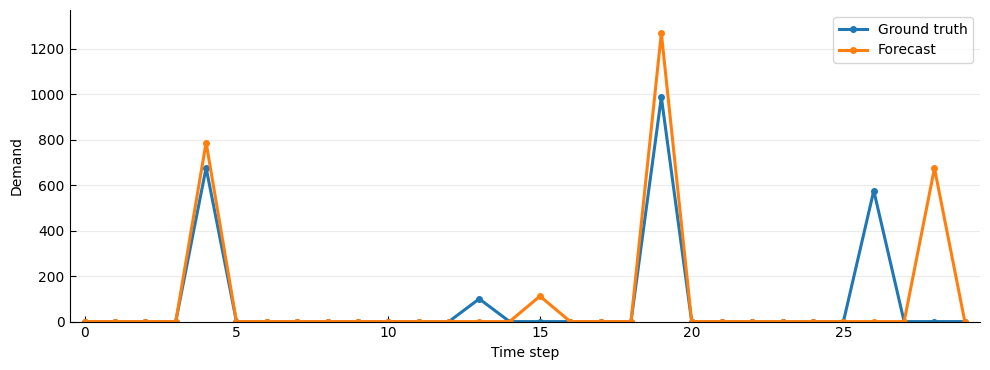

In [6]:
plot_forecast_vs_ground_truth(forecast=sample_forecast, ground_truth=sample_time_series)

Calculate the intermittent alignment error and its components from the sample time-series and forecast:

In [7]:
iae_summary_results = intermittent_alignment_error(ground_truth=sample_time_series, forecast=sample_forecast)
iae_summary_results

{'number_of_masks_used': 4,
 'recall_error': 0.14445609166313686,
 'precision_error': 0.18593859004074825,
 'mass_error': 0.04633504135909216,
 'in_time_error': 0.0040632505936114855,
 'intermittent_alignment_error': 0.12828084451743488}

Extract the final intermittent alignment metric score from the summary results:

In [8]:
iae_score = iae_summary_results['intermittent_alignment_error']
iae_score

0.12828084451743488

### A few different metric parameter configurations on the same sample:

Low timing tolerance:

In [9]:
iae_summary_results = intermittent_alignment_error(ground_truth=sample_time_series, forecast=sample_forecast, timing_tolerance=0)
iae_summary_results

{'number_of_masks_used': 1,
 'recall_error': 0.2889121833262737,
 'precision_error': 0.32050201629210295,
 'mass_error': 0.04633504135909216,
 'in_time_error': 0.0040632505936114855,
 'intermittent_alignment_error': 0.23197720527309196}

High timing tolerance:

In [10]:
iae_summary_results = intermittent_alignment_error(ground_truth=sample_time_series, forecast=sample_forecast, timing_tolerance=1)
iae_summary_results

{'number_of_masks_used': 7,
 'recall_error': 0.08254633809322107,
 'precision_error': 0.13860588024355447,
 'mass_error': 0.04633504135909216,
 'in_time_error': 0.0040632505936114855,
 'intermittent_alignment_error': 0.08973083405565613}

High in-time weight:

In [11]:
iae_summary_results = intermittent_alignment_error(ground_truth=sample_time_series, forecast=sample_forecast, in_time_weight=2)
iae_summary_results

{'number_of_masks_used': 4,
 'recall_error': 0.14445609166313686,
 'precision_error': 0.18593859004074825,
 'mass_error': 0.04633504135909216,
 'in_time_error': 0.0040632505936114855,
 'intermittent_alignment_error': 0.10735052655059665}

Demand rate setting:

In [12]:
iae_summary_results = intermittent_alignment_error(ground_truth=sample_time_series, forecast=sample_forecast, recall_weight=0, precision_weight=0)
iae_summary_results

{'number_of_masks_used': None,
 'recall_error': 0.0,
 'precision_error': 0.0,
 'mass_error': 0.04633504135909216,
 'in_time_error': 0.0040632505936114855,
 'intermittent_alignment_error': 0.03790506615605204}

# Visualise the error matrix on synthetic errors for a dataset (list of lists):

Standard parameters:

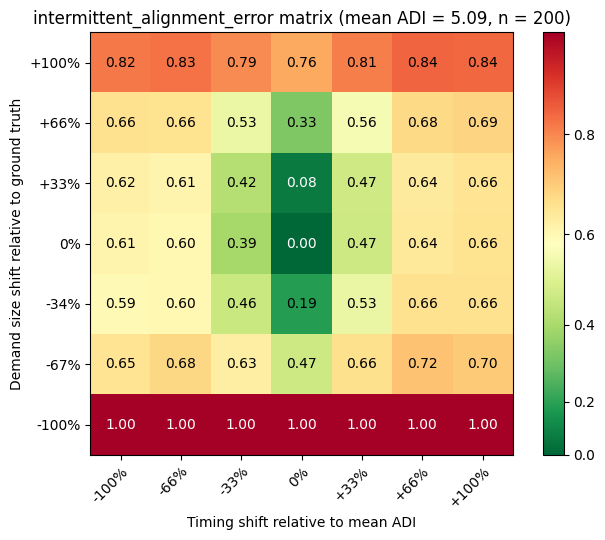

In [13]:
result = visualise_synthetic_error_matrix(
    time_series_samples=random_time_series_list,
    metric_function=intermittent_alignment_error,
    random_state=42
)

Lower timing tolerance and higher in-time weight:

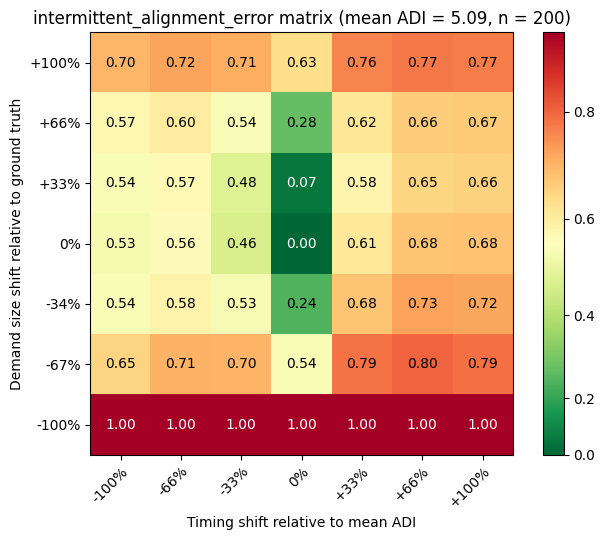

In [14]:
metric_params = {
    "recall_weight": 1.0,
    "precision_weight": 1.0,
    "mass_weight": 1.0,
    "in_time_weight": 2.0,
    "mode": "squared",
    "timing_tolerance": 0.5,
    "p": 2.0,
    "in_time_relevance_mode": "linear",
    "precision_adjustment_beta": 0.75,
}

result = visualise_synthetic_error_matrix(
    time_series_samples=random_time_series_list,
    metric_function=intermittent_alignment_error,
    metric_params=metric_params,
    random_state=42
)